In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf

In [13]:
# Needed Columns for the Hypothesis testing
#data_needed = ["Order Date", "Category", "Revenue", "Shipping Address State", "tavg"]

fashion_df = pd.read_csv("./data/fashion_data.csv")
fashion_df["Order Date"] = pd.to_datetime(fashion_df["Order Date"]) # Formating Order date back to Datetime dtype, in read_csv you cant set column to datetime so need to do manually
fashion_df.set_index("Order Date", inplace=True)
fashion_df.drop(columns=["Unnamed: 0"], inplace=True)


groceries_df = pd.read_csv("./data/grocery_data.csv")
groceries_df["Order Date"] = pd.to_datetime(groceries_df["Order Date"])
groceries_df.set_index("Order Date", inplace=True)
groceries_df.drop(columns=["Unnamed: 0"], inplace=True)

In [14]:
#transactions_temp = transactions_temp[~transactions_temp["Shipping Address State"].isin(["AK", "HI", "PR", "DC", "I did not reside in the United States"])] # Remove Shipping addresses without temperature information

In [15]:
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):
    maxlag = 12    
    
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

In [16]:
# List of states
states_list = groceries_df["Shipping Address State"].unique()

# Creating Filtered dataframe for Granger test
df_granger_grocerie = groceries_df[["Revenue", "tavg", "Shipping Address State"]]


#### First order diff for Revenue

In [17]:
state_p_values = {}
#states_list = ["FL"]
for i in range(len(states_list)): 
    try: 
        df_one_state = df_granger_grocerie[df_granger_grocerie["Shipping Address State"].isin([states_list[i]])].copy()

        # Remove Seasonality from Temp
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(2)

        df_one_state = df_one_state.iloc[365:, ]

        #Fist order Diff for Revenue
        first_order_diff = [0]

        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"][j] - df_one_state["Revenue"][j-1])

        df_one_state["first_order_diff_Revenue"] = first_order_diff


        df_one_state["Revenue_SMA30"] = df_one_state["Revenue"].rolling(30).mean().round(2)

        df_one_state["Temp_SMA30"] = df_one_state["Temp_No_Season"].rolling(30).mean().round(2)

        df_granger_groceries= df_one_state.iloc[30:, ].copy() #Note need to check how to deal with missing dates

        #granger_matrix = grangers_causation_matrix(df_granger_groceries ,variables=["Revenue", "Temp_No_Season"])
        granger_matrix = grangers_causation_matrix(df_granger_groceries ,variables=["first_order_diff_Revenue", "Temp_No_Season"])

        p_value = granger_matrix.iloc[0, 1]
        state_p_values[states_list[i]] = p_value

        print(f"For the state {states_list[i]} temperature as a predictor has a p-value of: {p_value}")
    except: 
        print(f"Error for state {states_list[i]}")
    


For the state AL temperature as a predictor has a p-value of: 0.3437
For the state AR temperature as a predictor has a p-value of: 0.2698
For the state AZ temperature as a predictor has a p-value of: 0.2754
For the state CA temperature as a predictor has a p-value of: 0.69
For the state CO temperature as a predictor has a p-value of: 0.4668
For the state CT temperature as a predictor has a p-value of: 0.0829
For the state DE temperature as a predictor has a p-value of: 0.0949
For the state FL temperature as a predictor has a p-value of: 0.5823
For the state GA temperature as a predictor has a p-value of: 0.4405
For the state IA temperature as a predictor has a p-value of: 0.3145
For the state ID temperature as a predictor has a p-value of: 0.2856
For the state IL temperature as a predictor has a p-value of: 0.5866
For the state IN temperature as a predictor has a p-value of: 0.0537
For the state KS temperature as a predictor has a p-value of: 0.2531
For the state KY temperature as a pr

In [18]:
state_p_values = {}
states_list = ["CA"]
i = 0
df_one_state = df_granger_grocerie[df_granger_grocerie["Shipping Address State"].isin([states_list[i]])].copy()


# Remove Seasonality from Temp
df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(2)

df_one_state = df_one_state.iloc[365:, ]

#Fist order Diff for Revenue
first_order_diff = [0]

for j in range(1,len(df_one_state)): 
    first_order_diff.append(df_one_state["Revenue"][j] - df_one_state["Revenue"][j-1])

df_one_state["first_order_diff_Revenue"] = first_order_diff


df_one_state["Revenue_SMA30"] = df_one_state["Revenue"].rolling(30).mean().round(2)

df_one_state["Temp_SMA30"] = df_one_state["Temp_No_Season"].rolling(30).mean().round(2)

df_granger_groceries= df_one_state.iloc[30:, ].copy()

granger_matrix = grangers_causation_matrix(df_granger_groceries ,variables=["Revenue", "Temp_No_Season"])

p_value = granger_matrix.iloc[0, 1]
state_p_values[states_list[i]] = p_value

print(f"For the state {states_list[i]} temperature as a predictor has a p-value of: {p_value}")


For the state CA temperature as a predictor has a p-value of: 0.0955


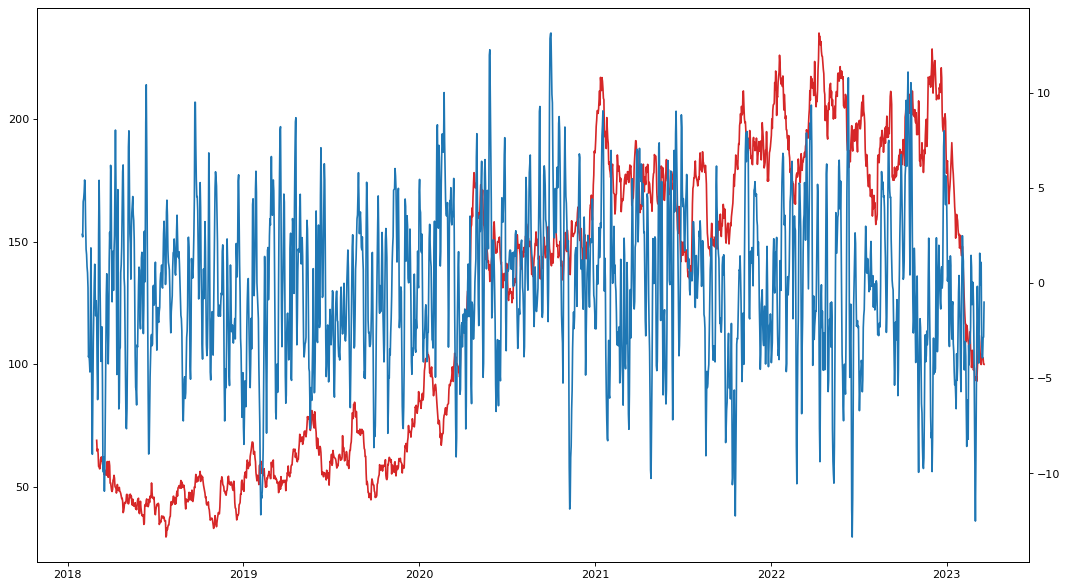

In [19]:
#CA_only = df_granger_grocerie[df_granger_grocerie["Shipping Address State"].isin(["CA"])].copy()
df_granger_groceries_plot = df_granger_groceries.reset_index()
# Plotting
fig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)


ax1.plot(df_granger_groceries_plot["Order Date"],
            df_granger_groceries_plot["Revenue_SMA30"].shift(30),
            color="tab:red")

# Second line
ax2 = ax1.twinx()
ax2.plot(df_granger_groceries_plot["Order Date"],
         df_granger_groceries_plot["Temp_No_Season"],
         color="tab:blue")

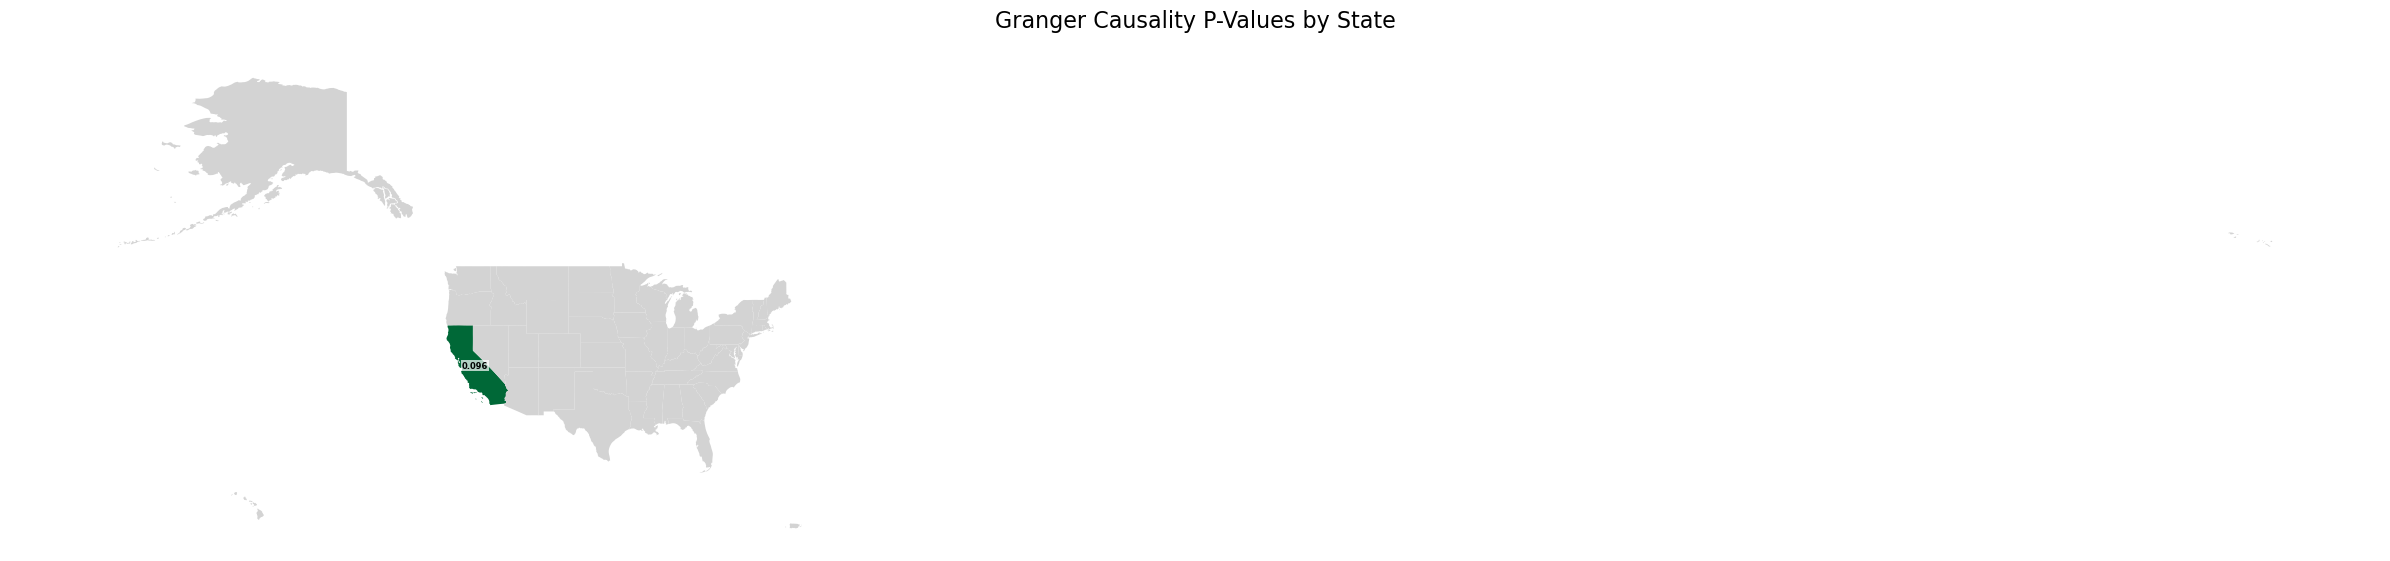

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Convert p-values to DataFrame
p_value_df = pd.DataFrame.from_dict(state_p_values, orient='index', columns=['p_value'])
p_value_df.index.name = 'state'

# Load US states shapefile
usa = gpd.read_file('https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_20m.zip')

# Convert state codes
usa['state'] = usa['STUSPS']

# Merge the p-values with the geographic data
usa = usa.merge(p_value_df, on='state', how='left')

# Create figure and axes with larger size
fig = plt.figure(figsize=(24, 14))
ax = fig.add_subplot(111)

# Create custom colormap from green to red
cmap = plt.cm.RdYlGn_r

# Plot the map
usa.plot(column='p_value',
         cmap=cmap,
         ax=ax,
         legend=False,
         missing_kwds={'color': 'lightgrey'})

# Add p-values as text in each state 
for idx, row in usa.iterrows():
    if not pd.isna(row['p_value']):
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, 
                f'{row["p_value"]:.3f}',  # Show 3 decimal places
                horizontalalignment='center',
                verticalalignment='center',
                fontsize=6,  # Reduced font size
                fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.5))  # Reduced padding

plt.title('Granger Causality P-Values by State', fontsize=16, pad=20)
ax.axis('off')

# Adjust layout to use full screen width
plt.tight_layout()

plt.show()

# Autocorrelation for first order Revenue lags

In [24]:
"""for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"][j] - df_one_state["Revenue"][j-1])"""

'for j in range(1,len(df_one_state)): \n            first_order_diff.append(df_one_state["Revenue"][j] - df_one_state["Revenue"][j-1])'

In [26]:
series = df_one_state["first_order_diff_Revenue"]

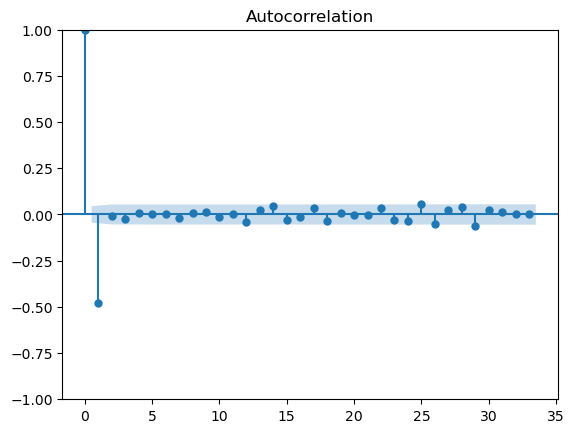

In [ ]:
plot_acf(series)
plt.show()

#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/

Shows that if there was a purchase on t=0 it is less likley that someone is purchasing at t=1. Makes sense since when you bought something you are unlikley to buy something imeadiatly the next day. 

## Approach 2

In [31]:

# using shift function to shift the values.
dataframe = pd.concat([series.shift(10), series.shift(9), series.shift(8), series.shift(7), series.shift(6), series.shift(5), series.shift(4),series.shift(3), series.shift(2),
					series.shift(1), series], axis=1)
# naming the columns
dataframe.columns = ['t', 't+1', 't+2', 't+3', 't+4', 't+5', 't+6', 't+7', 't+8', 't+9', 't+10']

# using corr() function to compute the correlation
result = dataframe.corr()

print(result)


             t       t+1       t+2       t+3       t+4       t+5       t+6  \
t     1.000000 -0.476298 -0.009187 -0.026158  0.009328  0.004348  0.004870   
t+1  -0.476298  1.000000 -0.476666 -0.009060 -0.025765  0.008866  0.004514   
t+2  -0.009187 -0.476666  1.000000 -0.476600 -0.009536 -0.025173  0.008653   
t+3  -0.026158 -0.009060 -0.476600  1.000000 -0.476450 -0.009633 -0.025136   
t+4   0.009328 -0.025765 -0.009536 -0.476450  1.000000 -0.476608 -0.009520   
t+5   0.004348  0.008866 -0.025173 -0.009633 -0.476608  1.000000 -0.476642   
t+6   0.004870  0.004514  0.008653 -0.025136 -0.009520 -0.476642  1.000000   
t+7  -0.016686  0.004653  0.004782  0.008605 -0.025276 -0.009347 -0.476673   
t+8   0.006781 -0.016660  0.004624  0.004786  0.008619 -0.025288 -0.009340   
t+9   0.013650  0.006883 -0.016782  0.004646  0.004855  0.008535 -0.025257   
t+10 -0.011098  0.013521  0.007036 -0.016808  0.004562  0.004953  0.008498   

           t+7       t+8       t+9      t+10  
t    -0.016686  